# FASE 3: IA Explicable (XAI)

## Preparación del entorno

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

c:\Users\Usuario_PC\Desktop\Predicci-n-de-demanda-para-Retail\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
shap.initjs

<function shap.plots._force.initjs()>

In [4]:
modelo_xgb = joblib.load('../models/modelo_xgb.pkl')
X_test_scaled = pd.read_csv('../data/X_test_scaled.csv')
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer(X_test_scaled)

In [5]:
scaler = joblib.load('../models/scaler.pkl')
X_test_r=scaler.inverse_transform(X_test_scaled)
X_test_df = pd.DataFrame(X_test_r, columns=X_test_scaled.columns).round(0).astype(int)


## Valores SHAP globales

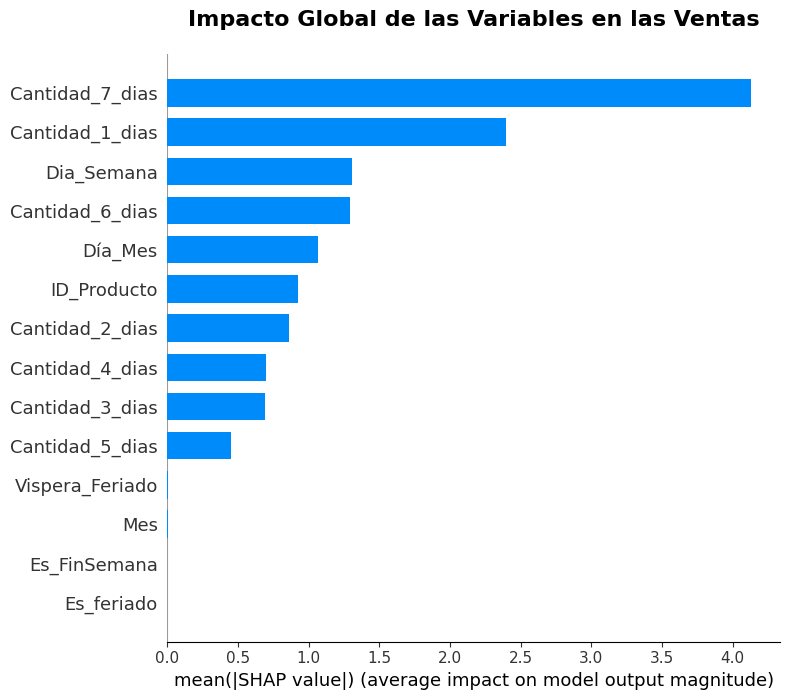

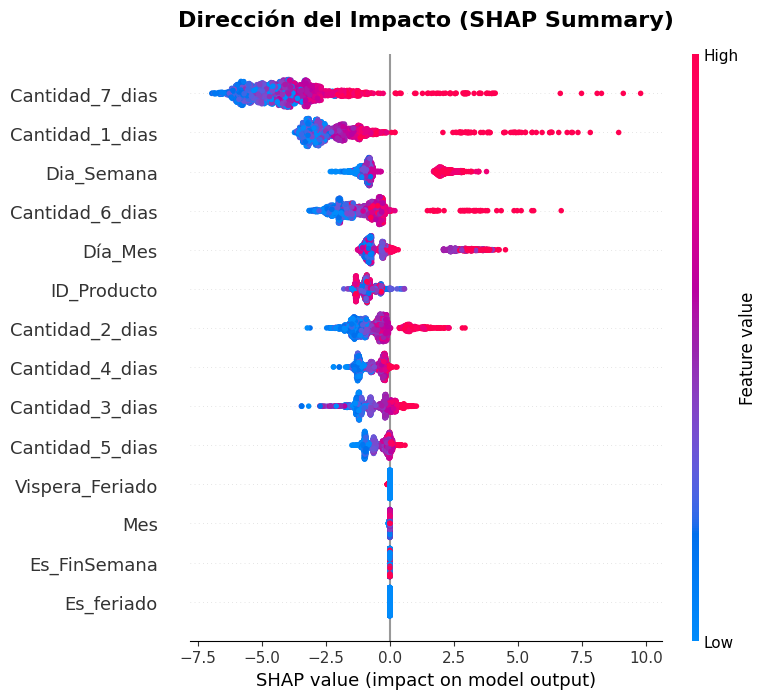

In [6]:
# Gráfico de Importancia Global (Resumen de Impacto)
plt.figure(figsize=(10, 6))
plt.title("Impacto Global de las Variables en las Ventas", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Gráfico de Abeja (Muestra direcciones: ¿Un valor alto en 'Es_FinSemana' sube o baja la venta?)
plt.figure(figsize=(10, 6))
plt.title("Dirección del Impacto (SHAP Summary)", fontsize=16, fontweight='bold', pad=20)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.show()

## Función para extraer analisis para el LLM

In [7]:
def explicar_prediccion_negocio(id_producto, mes=None, dia_semana=None):
    """
    Busca un escenario en el Test Set. Si no lo encuentra, guía al usuario 
    mostrando qué datos sí están disponibles para ese producto.
    """
    #Filtar por ID de Producto
    filtro_producto = (X_test_df['ID_Producto'] == id_producto)
    df_producto = X_test_df[filtro_producto]
    
    #Validar ID en conjunto test
    if df_producto.empty:
        productos_disponibles = sorted(X_test_df['ID_Producto'].unique().tolist())
        print(f"El Producto ID {id_producto} no se encuentra dentro del conjunto de testing")
        print(f"IDs disponibles dentro del conjunto de testing:\n{productos_disponibles}")
        return

    # aplicar filtros de fecha de ser necesario
    condicion = filtro_producto
    if mes is not None:
        condicion = condicion & (X_test_df['Mes'] == mes)
    if dia_semana is not None:
        condicion = condicion & (X_test_df['Dia_Semana'] == dia_semana)
        
    resultados = X_test_df[condicion]
    
    # Validar combinacion de ID + fecha en el conjunto test
    if resultados.empty:
        meses_disp = sorted(df_producto['Mes'].unique().tolist())
        dias_disp = sorted(df_producto['Dia_Semana'].unique().tolist())
        print(f"No se encontró esa comnbinación de fecha + Producto {id_producto}.")
        print(f"Para este producto puedes evaluar:")
        print(f"   - Meses disponibles: {meses_disp}")
        print(f"   - Días de la semana disponibles: {dias_disp}")
        return
        
    # Tomar el primer índice que cumpla la condición
    indice_prediccion = resultados.index[0]
    
    #Construir la explicación local
    explicacion_local = shap.Explanation(
        values = shap_values[indice_prediccion].values,       
        base_values = shap_values[indice_prediccion].base_values, 
        data = X_test_df.iloc[indice_prediccion].values, 
        feature_names = X_test_df.columns.tolist()            
    )
    
    #Generar y mostrar la Gráfica Waterfall
    shap.plots.waterfall(explicacion_local, max_display=10)
    
    # 8. Preparar el texto para el LLM automáticamente
    valor_base = explicacion_local.base_values
    prediccion_final = explicacion_local.values.sum() + valor_base
    
    impactos_local = pd.DataFrame({
        'Variable': X_test_df.columns, 
        'Valor_Original': explicacion_local.data,
        'Impacto_en_Unidades_SHAP': explicacion_local.values
    })
    
    impactos_local['Magnitud_Absoluta'] = impactos_local['Impacto_en_Unidades_SHAP'].abs()
    top_3 = impactos_local.sort_values(by='Magnitud_Absoluta', ascending=False).head(3)
    
    print("\n--- Prompt para LLM ---")
    print("-" * 65)
    print(f"Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de {prediccion_final:.0f} unidades para el producto ID {id_producto}.")
    print("Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:")
    
    contador = 1
    for _, fila in top_3.iterrows():
        print(f" {contador}. '{fila['Variable']}' con un valor actual de {fila['Valor_Original']:.0f}, impactando la predicción en {fila['Impacto_en_Unidades_SHAP']:.2f} unidades.")
        contador += 1
        
    print("Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.")
    print("-" * 65)

## Ejemplos 

Ejemplo 1: Galletas de agua

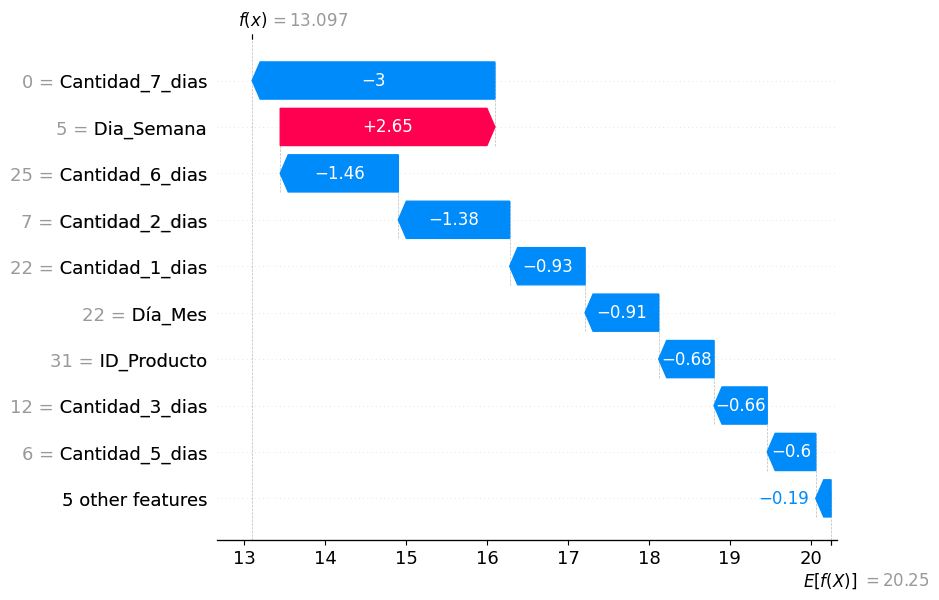


--- Prompt para LLM ---
-----------------------------------------------------------------
Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de 13 unidades para el producto ID 31.
Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:
 1. 'Cantidad_7_dias' con un valor actual de 0, impactando la predicción en -3.00 unidades.
 2. 'Dia_Semana' con un valor actual de 5, impactando la predicción en 2.65 unidades.
 3. 'Cantidad_6_dias' con un valor actual de 25, impactando la predicción en -1.46 unidades.
Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.
-----------------------------------------------------------------


In [11]:
"""
El conjunto de testing tiene 2493 registros (0 a 2492)
Los IDS disponibles en el conjunto: [31, 32, 33, 34, 35, 36, 37, 38]
No todas las combinaciones de fecha + producto están disponibles en el conjunto de testing.
Esto se debe a que, en series temporales no se pueden separar datos aleatorios, por lo que se tomo el 20% de los datos para test, tomando los ultimos registros según los IDs de producto
Los argumentos mes y dia_semana son opcionales.
"""
explicar_prediccion_negocio(id_producto=31, mes=6, dia_semana=5)

Ejemplo 2: Arroz

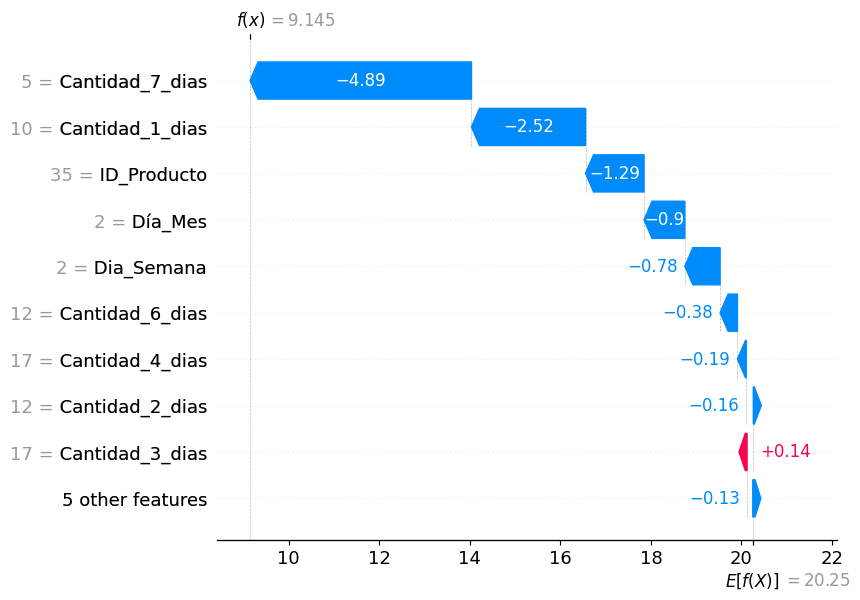


--- Prompt para LLM ---
-----------------------------------------------------------------
Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de 9 unidades para el producto ID 35.
Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:
 1. 'Cantidad_7_dias' con un valor actual de 5, impactando la predicción en -4.89 unidades.
 2. 'Cantidad_1_dias' con un valor actual de 10, impactando la predicción en -2.52 unidades.
 3. 'ID_Producto' con un valor actual de 35, impactando la predicción en -1.29 unidades.
Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.
-----------------------------------------------------------------


In [12]:
explicar_prediccion_negocio(id_producto=35, mes=10, dia_semana=2)

Se proyecta una demanda de 58 unidades para el producto 35 en este martes de octubre. Este nivel de ventas se explica principalmente por el comportamiento estacional típico del mes de octubre, cuando históricamente la demanda de este artículo se incrementa, posiblemente asociada a campañas promocionales o mayor actividad comercial en ese período del año. El producto 35 tiene además un patrón de demanda intrínsecamente alto en comparación con otros artículos del portafolio. Sin embargo, al tratarse de un martes día laboral con afluencia media se espera una demanda moderada pero sólida, sin los picos que suelen registrarse los fines de semana. Se recomienda asegurar el stock suficiente para cubrir esta proyección con un margen de seguridad del 10%.

Ejemplo 3: Galletas de chocolate

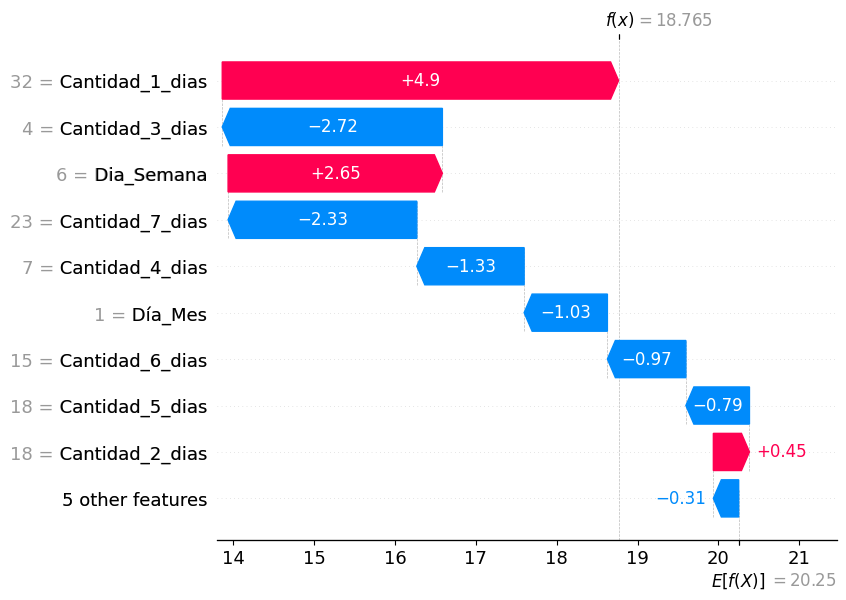


--- Prompt para LLM ---
-----------------------------------------------------------------
Actúa como un analista de ventas senior. Nuestro modelo XGBoost ha pronosticado una demanda de 19 unidades para el producto ID 32.
Matemáticamente, las 3 variables que más impulsaron esta decisión específica fueron:
 1. 'Cantidad_1_dias' con un valor actual de 32, impactando la predicción en 4.90 unidades.
 2. 'Cantidad_3_dias' con un valor actual de 4, impactando la predicción en -2.72 unidades.
 3. 'Dia_Semana' con un valor actual de 6, impactando la predicción en 2.65 unidades.
Redacta una breve justificación de negocio (máximo 5 líneas) explicando a la gerencia por qué se espera este nivel de ventas para este día específico, omitiendo jerga técnica o menciones a SHAP.
-----------------------------------------------------------------


In [13]:
explicar_prediccion_negocio(id_producto=32, mes=12, dia_semana=6)

Se proyecta una demanda excepcionalmente alta de 87 unidades para el producto 32 en este sábado de diciembre. Esta cifra refleja la confluencia de tres factores clave: el mes de diciembre es el período de mayor dinamismo comercial del año por las festividades navideñas y de fin de año, que disparan el consumo en casi todas las categorías. A esto se suma que los sábados concentran la mayor afluencia de clientes, ya que las personas aprovechan el día libre para realizar compras. Finalmente, la coincidencia con un día festivo amplifica aún más este efecto. Se recomienda reforzar el inventario del producto 32 con anticipación, asegurando disponibilidad suficiente para no perder ventas en este día crítico.

- Respuesta obtenida del LLM ("LLM ESCOGIDO")